# Learning via Uniform Convergence — Lecture 10: Visual Guide

This notebook follows the **Lecture 10** flow and builds intuition for:

- **Agnostic PAC learning**
- **Representative samples**
- **Uniform convergence**
- Why finite classes are agnostically PAC learnable via ERM (with bounded loss)

> Each section header points to the corresponding lecture slide range.
> Plain-English blocks unpack what each equation means and why it matters.

---

## Quick Recap (from realizable PAC)

For finite, realizable $\mathcal{H}$ with 0-1 loss:

$$
m \;\ge\; \left\lceil \frac{\log(|\mathcal{H}|/\delta)}{\epsilon} \right\rceil
$$

guarantees ERM returns $h_S$ with true error at most $\epsilon$ with probability at least $1-\delta$.

In this lecture we drop **realizability**, so we compare against the best hypothesis **inside** $\mathcal{H}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
np.random.seed(42)

# ============================================================
# Domain + noisy labeling model (unrealizable setting)
# ============================================================
X_MIN, X_MAX = -1.0, 1.0
X_GRID = np.linspace(X_MIN, X_MAX, 500)

def eta(x):
    '''
    eta(x) = P(Y=1|X=x), bounded away from {0,1} to induce noise.
    '''
    p = 0.5 + 0.35 * np.sin(2.3 * np.pi * x)
    return np.clip(p, 0.05, 0.95)

def bayes_predict(x):
    return (eta(x) >= 0.5).astype(int)

def sample_data(m, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = rng.uniform(X_MIN, X_MAX, size=m)
    y = rng.binomial(1, eta(x))
    return x, y

def threshold_predict(x, t):
    return (x >= t).astype(int)

def risk_01(yhat, y):
    return np.mean(yhat != y)

# Finite class H: threshold classifiers
THRESHOLDS = np.linspace(X_MIN, X_MAX, 31)
H_SIZE = len(THRESHOLDS)

def empirical_risk_threshold(x, y, t):
    return risk_01(threshold_predict(x, t), y)

def true_risk_threshold(t, n=60000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = rng.uniform(X_MIN, X_MAX, size=n)
    y = rng.binomial(1, eta(x))
    return risk_01(threshold_predict(x, t), y)

print(f"|H| = {H_SIZE} threshold hypotheses")

|H| = 31 threshold hypotheses


---
## Slides 6–11 — Agnostic PAC Motivation: Bayes Optimal vs Best-in-Class

When realizability fails, there may be irreducible noise. So the goal changes:

- **Bayes optimal predictor**: best possible predictor overall (not restricted to $\mathcal{H}$)
- **Best-in-class predictor**: best hypothesis available in our chosen class $\mathcal{H}$

### Breaking Down the Key Idea

---

#### In realizable PAC (old setting)

We asked for:

$$L_{\mathcal{D}}(h_S) \le \epsilon$$

because some perfect hypothesis existed in $\mathcal{H}$.

#### In agnostic PAC (new setting)

We ask for:

$$
L_{\mathcal{D}}(h_S) \le \min_{h\in\mathcal{H}}L_{\mathcal{D}}(h) + \epsilon
$$

So we only require ERM to be close to the **best available option** in $\mathcal{H}$.

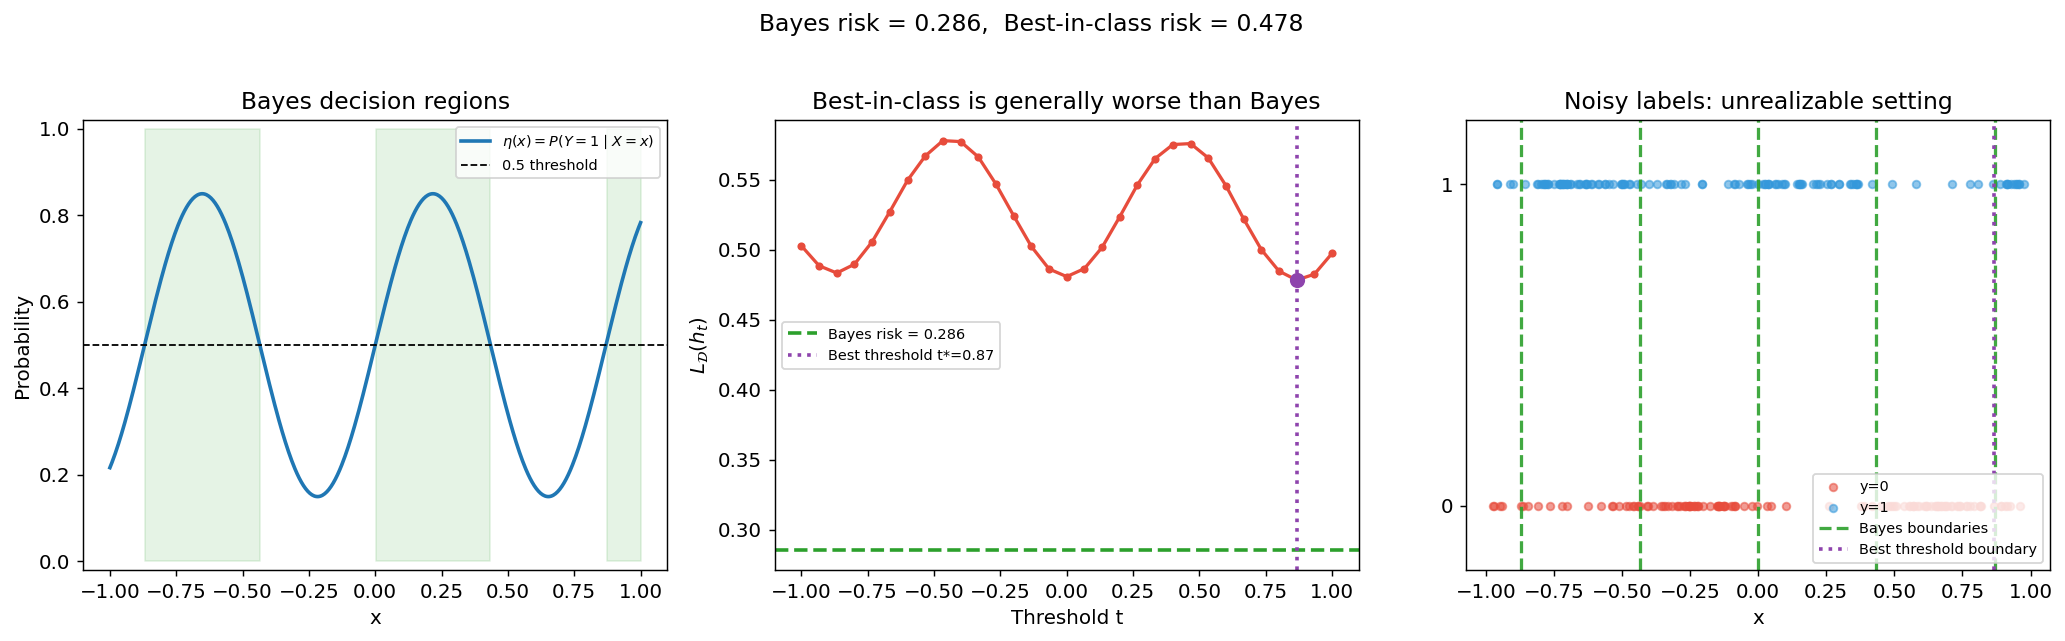

In [2]:
rng = np.random.default_rng(1)

# Approximate Bayes risk using dense Monte Carlo
x_mc = rng.uniform(X_MIN, X_MAX, size=120000)
y_mc = rng.binomial(1, eta(x_mc))

bayes_pred_mc = bayes_predict(x_mc)
bayes_risk = risk_01(bayes_pred_mc, y_mc)

thr_risks = np.array([risk_01(threshold_predict(x_mc, t), y_mc) for t in THRESHOLDS])
best_idx = np.argmin(thr_risks)
t_best = THRESHOLDS[best_idx]
best_in_class_risk = thr_risks[best_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- LEFT: eta(x) and Bayes rule ---
ax = axes[0]
ax.plot(X_GRID, eta(X_GRID), color="#1f77b4", linewidth=2, label=r"$\eta(x)=P(Y=1\mid X=x)$")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 threshold")
ax.fill_between(X_GRID, 0, 1, where=(bayes_predict(X_GRID) == 1), alpha=0.12, color="#2ca02c")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Bayes decision regions")
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.legend(fontsize=8)

# --- MIDDLE: risk over threshold class ---
ax = axes[1]
ax.plot(THRESHOLDS, thr_risks, marker="o", markersize=3.5, linewidth=1.8, color="#e74c3c")
ax.axhline(bayes_risk, color="#2ca02c", linestyle="--", linewidth=2, label=f"Bayes risk = {bayes_risk:.3f}")
ax.axvline(t_best, color="#8e44ad", linestyle=":", linewidth=2, label=f"Best threshold t*={t_best:.2f}")
ax.scatter([t_best], [best_in_class_risk], color="#8e44ad", s=55, zorder=5)
ax.set_title("Best-in-class is generally worse than Bayes")
ax.set_xlabel("Threshold t")
ax.set_ylabel(r"$L_{\mathcal{D}}(h_t)$")
ax.legend(fontsize=8)

# --- RIGHT: sample + two decision boundaries ---
ax = axes[2]
x_vis, y_vis = sample_data(250, rng=np.random.default_rng(10))
ax.scatter(x_vis[y_vis == 0], np.zeros(np.sum(y_vis == 0)), color="#e74c3c", alpha=0.55, s=18, label="y=0")
ax.scatter(x_vis[y_vis == 1], np.ones(np.sum(y_vis == 1)), color="#3498db", alpha=0.55, s=18, label="y=1")
# Bayes decision can switch at multiple x values where eta(x)=0.5.
eta_centered = eta(X_GRID) - 0.5
change_idx = np.where(np.diff(np.sign(eta_centered)) != 0)[0]
bayes_boundaries = X_GRID[change_idx]
for j, xb in enumerate(bayes_boundaries):
    lab = "Bayes boundaries" if j == 0 else None
    ax.axvline(xb, color="#2ca02c", linewidth=1.8, linestyle="--", alpha=0.9, label=lab)
ax.axvline(t_best, color="#8e44ad", linewidth=2, linestyle=":", label="Best threshold boundary")
ax.set_ylim(-0.2, 1.2)
ax.set_title("Noisy labels: unrealizable setting")
ax.set_xlabel("x")
ax.set_yticks([0, 1])
ax.legend(fontsize=8, loc="lower right")

fig.suptitle(
    f"Bayes risk = {bayes_risk:.3f},  Best-in-class risk = {best_in_class_risk:.3f}",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## Slides 10–11 — Agnostic PAC Learning (Formal Goal)

For loss $\ell$ and class $\mathcal{H}$, agnostic PAC asks for an algorithm such that, for all distributions:

$$
\Pr\!\left[L_{\mathcal{D}}(h_S) \le \inf_{h\in\mathcal{H}}L_{\mathcal{D}}(h) + \epsilon\right] \ge 1-\delta
$$

for sample size $m \ge m_{\mathcal{H}}(\epsilon,\delta)$.

### Breaking Down the Equation

---

#### $\inf_{h\in\mathcal{H}}L_{\mathcal{D}}(h)$

The lowest possible true loss available inside your chosen class.  
This is your **reference point** in the unrealizable case.

#### $+\epsilon$

Allowed optimization/generalization slack beyond best-in-class.

#### Probability $\ge 1-\delta$

The guarantee should hold with high confidence over the random draw of the training sample.

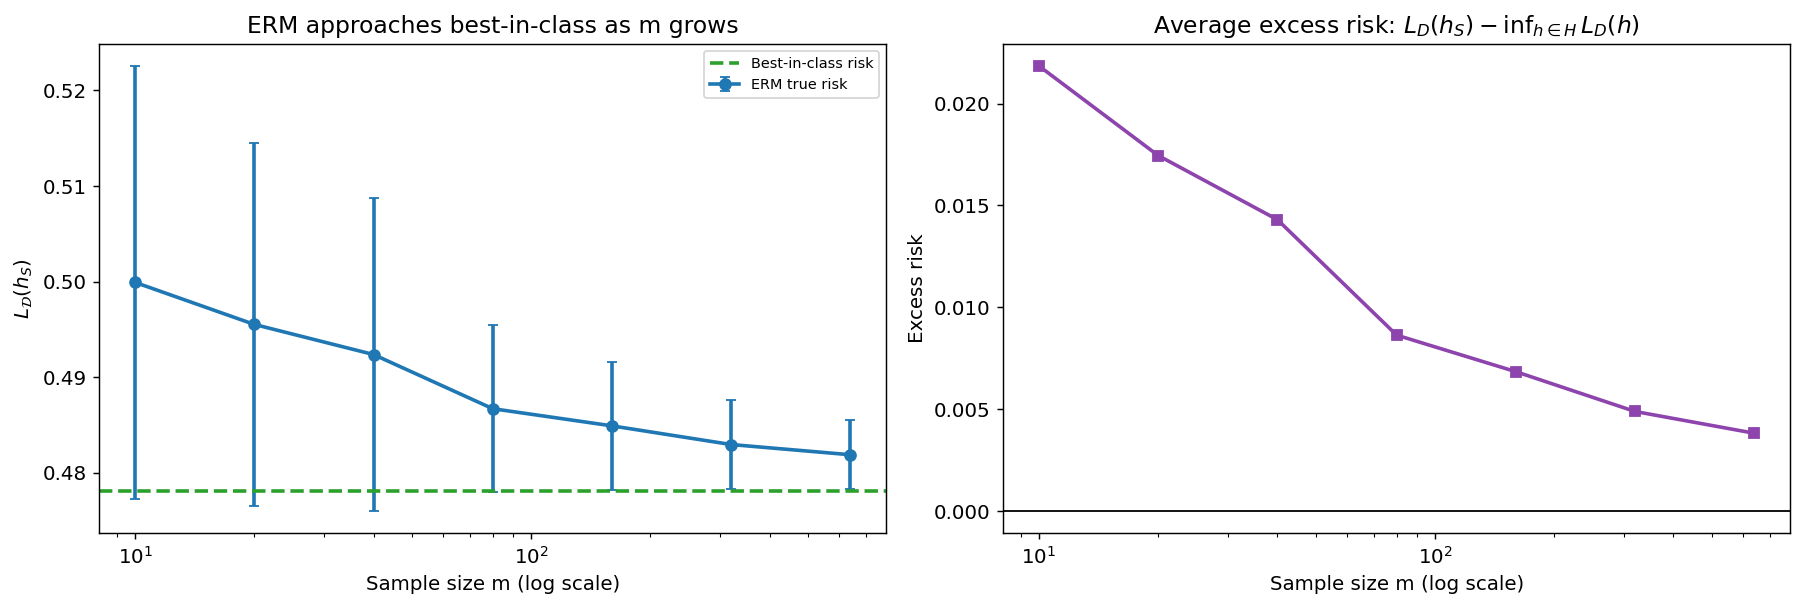

In [3]:
rng = np.random.default_rng(7)

# Approximate fixed true risks for each hypothesis
x_eval = rng.uniform(X_MIN, X_MAX, size=90000)
y_eval = rng.binomial(1, eta(x_eval))
true_risks = np.array([risk_01(threshold_predict(x_eval, t), y_eval) for t in THRESHOLDS])
opt_risk = np.min(true_risks)

def erm_threshold(x, y, thresholds=THRESHOLDS):
    emp = np.array([empirical_risk_threshold(x, y, t) for t in thresholds])
    return thresholds[np.argmin(emp)]

m_vals = np.array([10, 20, 40, 80, 160, 320, 640])
n_trials = 450

mean_erm_risk = []
std_erm_risk = []
mean_excess = []

for m in m_vals:
    risks = []
    for _ in range(n_trials):
        x_s, y_s = sample_data(m, rng=np.random.default_rng())
        t_hat = erm_threshold(x_s, y_s)
        idx = np.argmin(np.abs(THRESHOLDS - t_hat))
        risks.append(true_risks[idx])
    risks = np.array(risks)
    mean_erm_risk.append(np.mean(risks))
    std_erm_risk.append(np.std(risks))
    mean_excess.append(np.mean(risks - opt_risk))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.errorbar(m_vals, mean_erm_risk, yerr=std_erm_risk, marker="o", linewidth=2, capsize=3, label="ERM true risk")
ax.axhline(opt_risk, color="#2ca02c", linestyle="--", linewidth=2, label="Best-in-class risk")
ax.set_xscale("log")
ax.set_title("ERM approaches best-in-class as m grows")
ax.set_xlabel("Sample size m (log scale)")
ax.set_ylabel(r"$L_{\mathcal{D}}(h_S)$")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(m_vals, mean_excess, marker="s", linewidth=2, color="#8e44ad")
ax.axhline(0, color="black", linewidth=1)
ax.set_xscale("log")
ax.set_title(r"Average excess risk: $L_D(h_S)-\inf_{h\in H}L_D(h)$")
ax.set_xlabel("Sample size m (log scale)")
ax.set_ylabel("Excess risk")

plt.tight_layout()
plt.show()

---
## Slides 13–16 — $\epsilon$-Representative Samples

The lecture introduces the idea that a sample is representative if empirical and true losses are close **for all hypotheses**:

$$
\sup_{h\in\mathcal{H}}\left|L_S(h)-L_{\mathcal{D}}(h)\right| \le \epsilon
$$

### Why this matters

If your sample behaves like the population uniformly over $\mathcal{H}$, then ERM cannot be fooled badly by training noise.

### Breaking Down the Supremum

---

#### For a single hypothesis

$|L_S(h)-L_D(h)|$ is the train-vs-true mismatch for one $h$.

#### For the whole class

$\sup_h$ takes the worst mismatch across all hypotheses.  
Uniform convergence is about controlling this worst case.

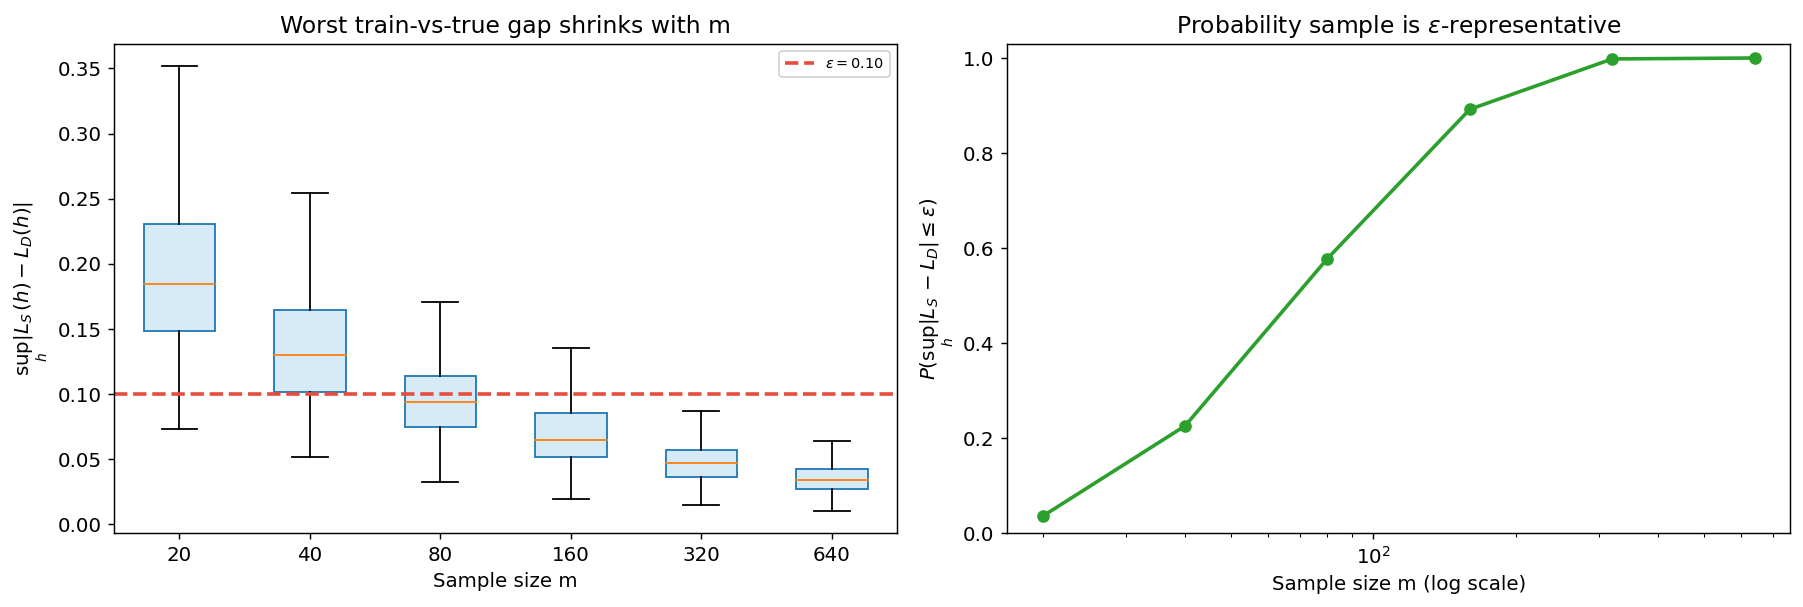

In [4]:
rng = np.random.default_rng(11)

# Precompute approximate true risks
x_true = rng.uniform(X_MIN, X_MAX, size=140000)
y_true = rng.binomial(1, eta(x_true))
L_D = np.array([risk_01(threshold_predict(x_true, t), y_true) for t in THRESHOLDS])

def uniform_gap_for_sample(x_s, y_s):
    L_S = np.array([empirical_risk_threshold(x_s, y_s, t) for t in THRESHOLDS])
    return np.max(np.abs(L_S - L_D))

eps = 0.10
m_vals = np.array([20, 40, 80, 160, 320, 640])
n_trials = 500

all_gaps = []
rep_probs = []

for m in m_vals:
    gaps = []
    for _ in range(n_trials):
        x_s, y_s = sample_data(m, rng=np.random.default_rng())
        gaps.append(uniform_gap_for_sample(x_s, y_s))
    gaps = np.array(gaps)
    all_gaps.append(gaps)
    rep_probs.append(np.mean(gaps <= eps))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
positions = np.arange(len(m_vals)) + 1
bp = ax.boxplot(all_gaps, positions=positions, widths=0.55, patch_artist=True, showfliers=False)
for box in bp["boxes"]:
    box.set(facecolor="#d6eaf8", edgecolor="#1f77b4")
ax.axhline(eps, color="#e74c3c", linestyle="--", linewidth=2, label=fr"$\epsilon={eps:.2f}$")
ax.set_xticks(positions)
ax.set_xticklabels([str(m) for m in m_vals])
ax.set_xlabel("Sample size m")
ax.set_ylabel(r"$\sup_h |L_S(h)-L_D(h)|$")
ax.set_title("Worst train-vs-true gap shrinks with m")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(m_vals, rep_probs, marker="o", linewidth=2, color="#2ca02c")
ax.set_xscale("log")
ax.set_ylim(0, 1.03)
ax.set_title(fr"Probability sample is $\epsilon$-representative")
ax.set_xlabel("Sample size m (log scale)")
ax.set_ylabel(r"$P(\sup_h |L_S-L_D| \leq \epsilon)$")

plt.tight_layout()
plt.show()

---
## Slides 17–20 — Uniform Convergence is Sufficient for Agnostic PAC

The lecture chain is:

1. **Uniform convergence** gives representative samples with high probability.
2. Representative samples imply ERM is near best-in-class.
3. Therefore ERM is agnostically PAC learnable.

### Core Lemma Intuition

If $S$ is $\epsilon/2$-representative, then:

$$
L_D(h_S) \le \inf_{h\in H}L_D(h) + \epsilon
$$

A common equivalent bound is:

$$
L_D(h_S) - \inf_{h\in H}L_D(h) \le 2\sup_{h\in H}|L_S(h)-L_D(h)|.
$$

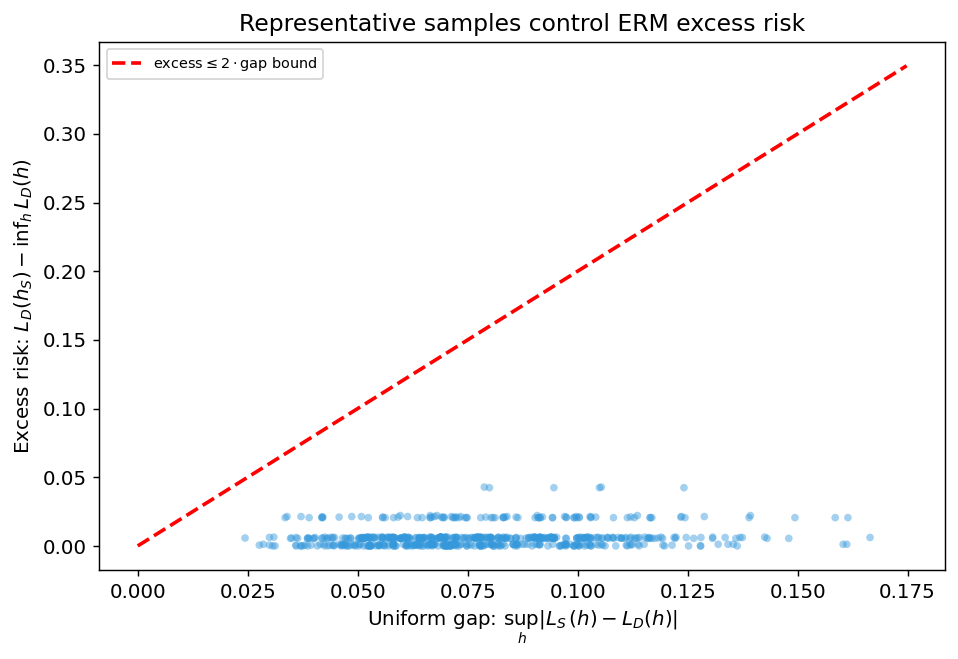

In [5]:
rng = np.random.default_rng(21)

x_true = rng.uniform(X_MIN, X_MAX, size=120000)
y_true = rng.binomial(1, eta(x_true))
L_D = np.array([risk_01(threshold_predict(x_true, t), y_true) for t in THRESHOLDS])
L_D_best = np.min(L_D)

def trial_stats(m, rng_local):
    x_s, y_s = sample_data(m, rng=rng_local)
    L_S = np.array([empirical_risk_threshold(x_s, y_s, t) for t in THRESHOLDS])
    h_idx = np.argmin(L_S)
    excess = L_D[h_idx] - L_D_best
    gap = np.max(np.abs(L_S - L_D))
    return gap, excess

m = 120
n_trials = 650
gaps = []
excesses = []
for _ in range(n_trials):
    g, e = trial_stats(m, np.random.default_rng())
    gaps.append(g)
    excesses.append(e)
gaps = np.array(gaps)
excesses = np.array(excesses)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.scatter(gaps, excesses, alpha=0.45, s=18, color="#3498db", edgecolors="none")
xline = np.linspace(0, max(gaps.max(), excesses.max()) * 1.05, 200)
ax.plot(xline, 2 * xline, "r--", linewidth=2, label=r"$\mathrm{excess} \leq 2\cdot \mathrm{gap}$ bound")
ax.set_xlabel(r"Uniform gap: $\sup_h |L_S(h)-L_D(h)|$")
ax.set_ylabel(r"Excess risk: $L_D(h_S)-\inf_h L_D(h)$")
ax.set_title("Representative samples control ERM excess risk")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Slides 21–25 — Finite Classes: Union Bound Setup

To show uniform convergence for finite $\mathcal{H}$, we bound:

$$
\Pr\!\left[\sup_{h\in\mathcal{H}} |L_S(h)-L_D(h)| > \epsilon\right].
$$

For finite classes with bounded loss in $[0,1]$, combining union bound + Hoeffding gives:

$$
\Pr\!\left[\sup_{h\in\mathcal{H}} |L_S(h)-L_D(h)| > \epsilon\right]
\le 2|\mathcal{H}|\,e^{-2m\epsilon^2}.
$$

This is the core quantitative engine behind agnostic sample complexity.

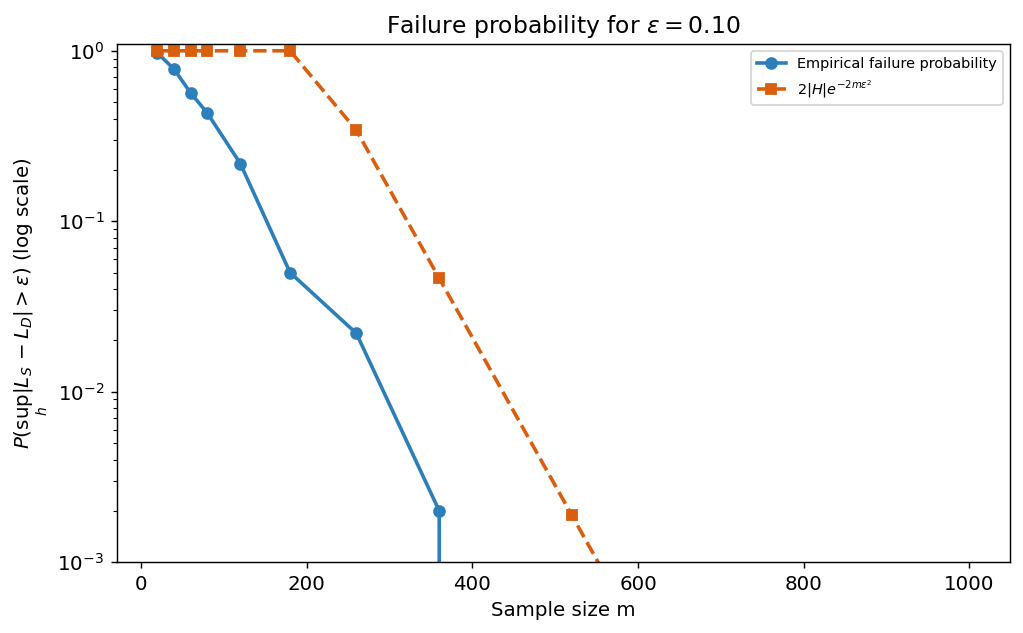

In [6]:
rng = np.random.default_rng(31)

# True risks for class
x_true = rng.uniform(X_MIN, X_MAX, size=150000)
y_true = rng.binomial(1, eta(x_true))
L_D = np.array([risk_01(threshold_predict(x_true, t), y_true) for t in THRESHOLDS])

eps = 0.10
m_vals = np.array([20, 40, 60, 80, 120, 180, 260, 360, 520, 760, 1000])
n_trials = 500

fail_emp = []
fail_bound = []

for m in m_vals:
    fails = 0
    for _ in range(n_trials):
        x_s, y_s = sample_data(m, rng=np.random.default_rng())
        L_S = np.array([empirical_risk_threshold(x_s, y_s, t) for t in THRESHOLDS])
        gap = np.max(np.abs(L_S - L_D))
        if gap > eps:
            fails += 1
    fail_emp.append(fails / n_trials)
    fail_bound.append(min(1.0, 2 * H_SIZE * np.exp(-2 * m * eps**2)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(m_vals, fail_emp, "o-", linewidth=2, color="#2c7fb8", label="Empirical failure probability")
ax.plot(m_vals, fail_bound, "s--", linewidth=2, color="#d95f0e", label=r"$2|H|e^{-2m\epsilon^2}$")
ax.set_yscale("log")
ax.set_ylim(1e-3, 1.1)
ax.set_title(fr"Failure probability for $\epsilon={eps:.2f}$")
ax.set_xlabel("Sample size m")
ax.set_ylabel(r"$P(\sup_h |L_S-L_D|>\epsilon)$ (log scale)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Slides 26–36 — Concentration and Hoeffding's Inequality

For i.i.d. bounded random variables $Z_i \in [0,1]$ with mean $\mu$:

$$
\Pr\!\left[\left|\frac{1}{m}\sum_{i=1}^m Z_i - \mu\right| > \epsilon\right]
\le 2e^{-2m\epsilon^2}.
$$

### Why this appears in uniform convergence proofs

For each fixed hypothesis $h$, the empirical loss is an average of bounded random variables, so Hoeffding controls its deviation from true loss.  
Then union bound extends from one $h$ to all hypotheses in finite $\mathcal{H}$.

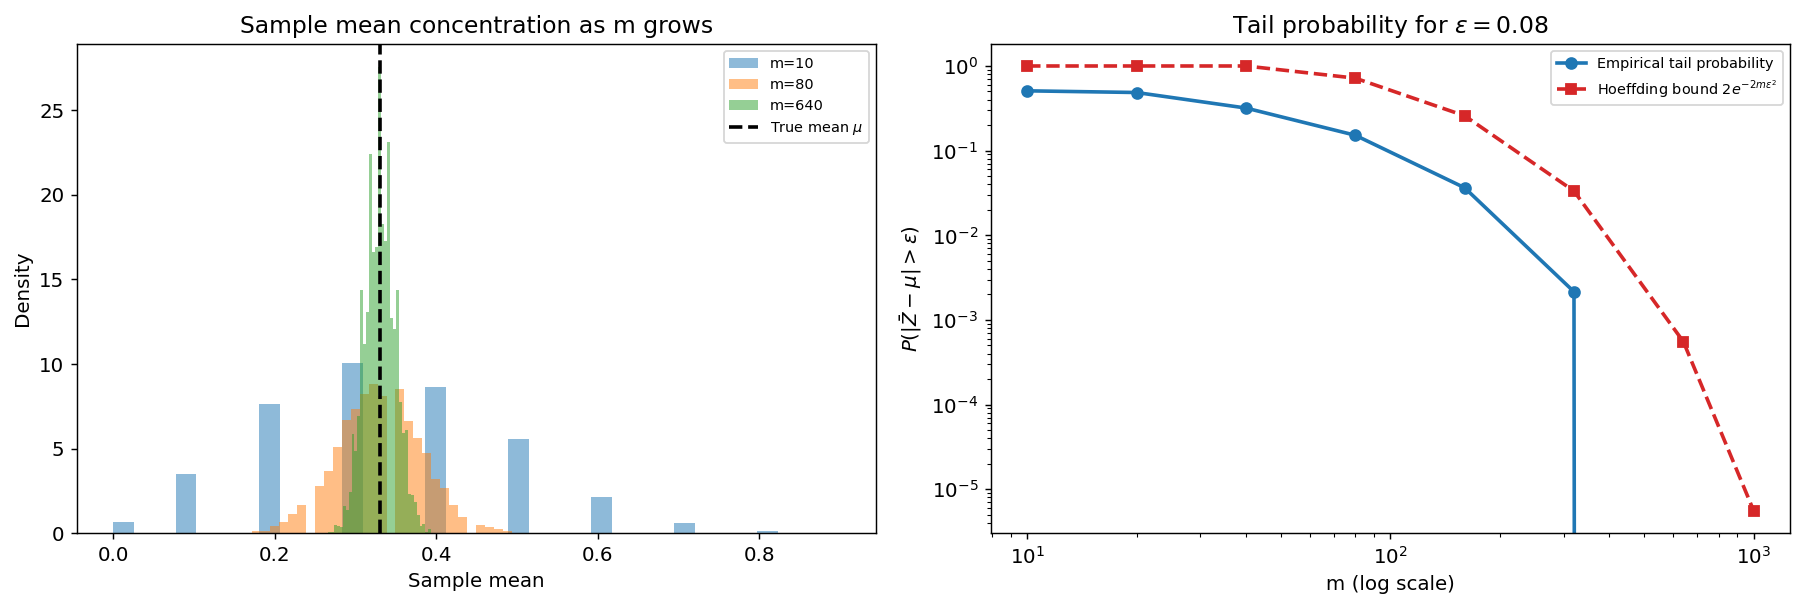

In [7]:
rng = np.random.default_rng(44)

mu = 0.33               # Bernoulli mean
eps = 0.08
m_vals = np.array([10, 20, 40, 80, 160, 320, 640, 1000])
n_trials = 20000

emp_probs = []
hoeff = []

for m in m_vals:
    samples = rng.binomial(1, mu, size=(n_trials, m))
    means = samples.mean(axis=1)
    emp_probs.append(np.mean(np.abs(means - mu) > eps))
    hoeff.append(min(1.0, 2 * np.exp(-2 * m * eps**2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
for m in [10, 80, 640]:
    samples = rng.binomial(1, mu, size=(7000, m))
    means = samples.mean(axis=1)
    ax.hist(means, bins=35, alpha=0.5, density=True, label=f"m={m}")
ax.axvline(mu, color="black", linestyle="--", linewidth=2, label=r"True mean $\mu$")
ax.set_title("Sample mean concentration as m grows")
ax.set_xlabel("Sample mean")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(m_vals, emp_probs, "o-", linewidth=2, color="#1f77b4", label="Empirical tail probability")
ax.plot(m_vals, hoeff, "s--", linewidth=2, color="#d62728", label=r"Hoeffding bound $2e^{-2m\epsilon^2}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(fr"Tail probability for $\epsilon={eps:.2f}$")
ax.set_xlabel("m (log scale)")
ax.set_ylabel(r"$P(|\bar{Z}-\mu|>\epsilon)$")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Slides 37–44 — Final Bound and PAC vs Agnostic Comparison

For finite $\mathcal{H}$ and bounded loss in $[0,1]$, ERM is agnostically PAC learnable.  
Using the lecture chain (uniform gap target set to $\epsilon/2$ for excess-risk target $\epsilon$), one sufficient sample size is:

$$
m \;\gtrsim\; \frac{2\log(2|\mathcal{H}|/\delta)}{\epsilon^2}.
$$

Compare with realizable PAC:

$$
m \;\gtrsim\; \frac{\log(|\mathcal{H}|/\delta)}{\epsilon}.
$$

Dropping realizability typically changes dependence from $1/\epsilon$ to $1/\epsilon^2$.

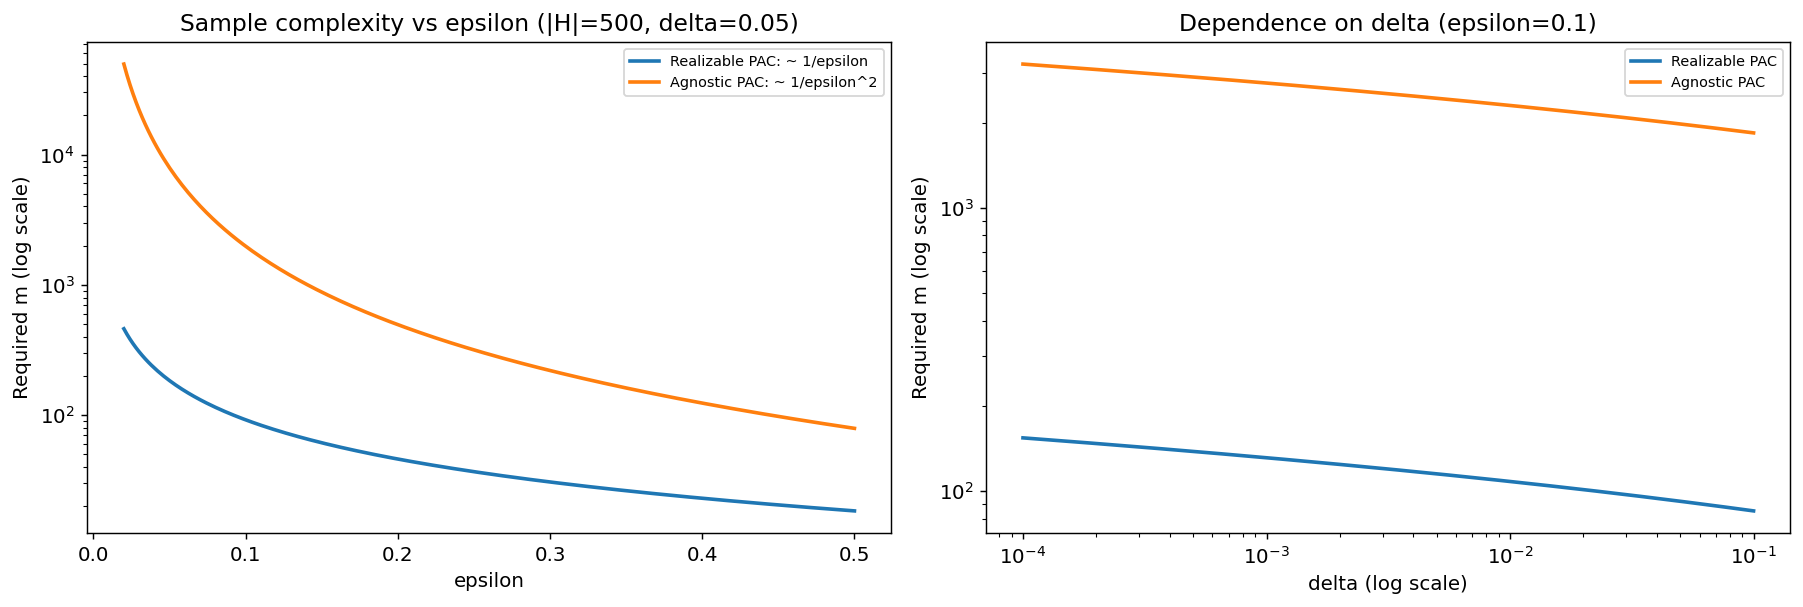

In [8]:
H = 500
delta = 0.05
eps_grid = np.linspace(0.02, 0.5, 240)

m_pac = np.log(H / delta) / eps_grid
m_agn = 2 * np.log(2 * H / delta) / (eps_grid**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.plot(eps_grid, m_pac, linewidth=2, label="Realizable PAC: ~ 1/epsilon")
ax.plot(eps_grid, m_agn, linewidth=2, label="Agnostic PAC: ~ 1/epsilon^2")
ax.set_yscale("log")
ax.set_title(f"Sample complexity vs epsilon (|H|={H}, delta={delta})")
ax.set_xlabel("epsilon")
ax.set_ylabel("Required m (log scale)")
ax.legend(fontsize=8)

ax = axes[1]
eps_fixed = 0.10
delta_vals = np.logspace(-4, -1, 130)
m_pac_d = np.log(H / delta_vals) / eps_fixed
m_agn_d = 2 * np.log(2 * H / delta_vals) / (eps_fixed**2)
ax.plot(delta_vals, m_pac_d, linewidth=2, label="Realizable PAC")
ax.plot(delta_vals, m_agn_d, linewidth=2, label="Agnostic PAC")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Dependence on delta (epsilon={eps_fixed})")
ax.set_xlabel("delta (log scale)")
ax.set_ylabel("Required m (log scale)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Summary

### Main reasoning chain

1. **Uniform convergence** controls train-vs-true loss gaps uniformly over $\mathcal{H}$.
2. Uniformly representative samples imply ERM has small **excess risk**.
3. Therefore uniform convergence is sufficient for **agnostic PAC learnability**.
4. For finite classes (bounded loss), union bound + Hoeffding prove uniform convergence.

### Key conceptual shift from realizable PAC

- Old target: absolute small risk ($L_D(h_S)\le\epsilon$)
- New target: near-best-in-class risk ($L_D(h_S)\le \inf_h L_D(h)+\epsilon$)

### Practical interpretation

Uniform convergence is the bridge from optimization on training data to guaranteed generalization under distributional sampling assumptions.